In [ ]:
from pathlib import Path

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

SYNTHETIC_DATA_DIR = REPO_ROOT / 'data' / 'synthetic'
RAW_DATA_DIR = REPO_ROOT / 'data' / 'raw'


## Madgiwck Filter for Synthetic Pendulum Data
This notebook applies the IMU-only Madgwick orientation filter (Madgwick, 2010) to one 
trial of synthetic pendulum data (seed 42).

In [6]:
import numpy as np
import matplotlib.pyplot as plt
# Load the synthetic pendulum
synthetic_data = np.load(SYNTHETIC_DATA_DIR / 'synthetic_data_pendulum_seed42.npz', allow_pickle=True)

In [7]:
def normalize(v, eps=1e-12):
    # Return unit vector
    norm = np.linalg.norm(v)
    if norm < eps:
        return v
    return v / norm

def quat_to_euler(q):
    """
    Convert quaternion [q1, q2, q3, q4] to roll, pitch, yaw (radians).
    q1 is the scalar part (w), q2, q3, q4 are the vector parts (x, y, z). 
    """
    q1, q2, q3, q4 = q

    # roll 
    roll = np.arctan2(
        2.0 * (q1*q2 + q3*q4),
        1.0 - 2.0 * (q2*q2 + q3*q3)
    )

    # pitch
    sin_pitch = 2.0 * (q1*q3 - q4*q2)
    sin_pitch = np.clip(sin_pitch, -1.0, 1.0)
    pitch = np.arcsin(sin_pitch)

    # yaw
    yaw = np.arctan2(
        2.0 * (q1*q4 + q2*q3),
        1.0 - 2.0 * (q3*q3 + q4*q4)
    )

    return np.array([roll, pitch, yaw])

def quats_to_euler(q_est):
    return np.array([quat_to_euler(q) for q in q_est])


def madgwick_update_imu(q, gyro, accel, dt, beta=0.3):
    """
    One timestep of the IMU-only Madgwick filter.

    The filter estimates orientation as a quaternion q. 
    We followed https://web.enib.fr/~kerhoas/iot/reseau-de-capteurs/carte-imu-mpu9250/documents/INVENSENSE/madgwick_internal_report.pdf

    Parameters
    ----------
    q : shape (4,)
        Current quaternion [q1, q2, q3, q4]. q1 is scalar part.
    gyro : shape (3,)
        Gyroscope measurement [gx, gy, gz] in rad/s.
    accel : shape (3,)
        Accelerometer measurement [ax, ay, az].
    dt : float
        Sampling period in seconds.
    beta : float
        Filter gain controlling trust in accelerometer vs gyroscope.
        Higher beta = more correction from accelerometer.

    Returns
    -------
    q_new : np.ndarray, shape (4,)
        Updated normalized quaternion.
    """
    q1, q2, q3, q4 = q
    gx, gy, gz = gyro
    ax, ay, az = accel

    # normalize accelerometer measurement 
    accel_norm = np.linalg.norm(accel)
    if accel_norm < 1e-12:
        return normalize(q)
    ax, ay, az = accel / accel_norm

    # objective function f_g(q, a) (equation (25) in Madgwick's report)
    f = np.array([
        2.0 * (q2*q4 - q1*q3) - ax,
        2.0 * (q1*q2 + q3*q4) - ay,
        2.0 * (0.5 - q2*q2 - q3*q3) - az
    ])

    # Jacobian J_g(q) (equation (26))
    J = np.array([
        [-2.0*q3,  2.0*q4, -2.0*q1,  2.0*q2],
        [ 2.0*q2,  2.0*q1,  2.0*q4,  2.0*q3],
        [ 0.0,    -4.0*q2, -4.0*q3,  0.0   ]
    ])

    # Gradient of the objective in quaternion space
    grad = J.T @ f
    grad = normalize(grad)

    # Quaternion derivative from gyroscope integration (pure quaternion kinematics)
    # q_dot = 0.5 * q ⊗ [0, gx, gy, gz]
    q_dot_omega = 0.5 * np.array([
        -q2*gx - q3*gy - q4*gz,
         q1*gx + q3*gz - q4*gy,
         q1*gy - q2*gz + q4*gx,
         q1*gz + q2*gy - q3*gx
    ])

    # gyroscope derivative with accelerometer gradient correction
    q_dot = q_dot_omega - beta * grad
    q_new = q + q_dot * dt # euler
    q_new = normalize(q_new)

    return q_new


def run_madgwick_imu(gyro_data, accel_data, dt, beta=0.3):
    """
    Run the Madgwick filter over a full sequence of IMU measurements.
    """
    N = len(gyro_data)

    q_est = np.zeros((N, 4))
    q_est[0] = np.array([1.0, 0.0, 0.0, 0.0])  # initialize with dentity quaternion: zero initial rotation

    for k in range(1, N):
        q_est[k] = madgwick_update_imu(
            q=q_est[k-1],
            gyro=gyro_data[k],
            accel=accel_data[k],
            dt=dt,
            beta=beta
        )

    return q_est

In [8]:
# Run the Madgwick filter on the synthetic data
Z_synthetic = synthetic_data['Z']
accel_data = Z_synthetic[:, :3] # ax, ay, az are the first 3 columns
gyro_data = Z_synthetic[:, 3:]  # wx, wy, wz are the last 3 columns
dt = 1 / 100

q_estimated = run_madgwick_imu(gyro_data, accel_data, dt)
euler_angles = quats_to_euler(q_estimated)

In [9]:
## Plotting the Estimated Angles and Ground Truth

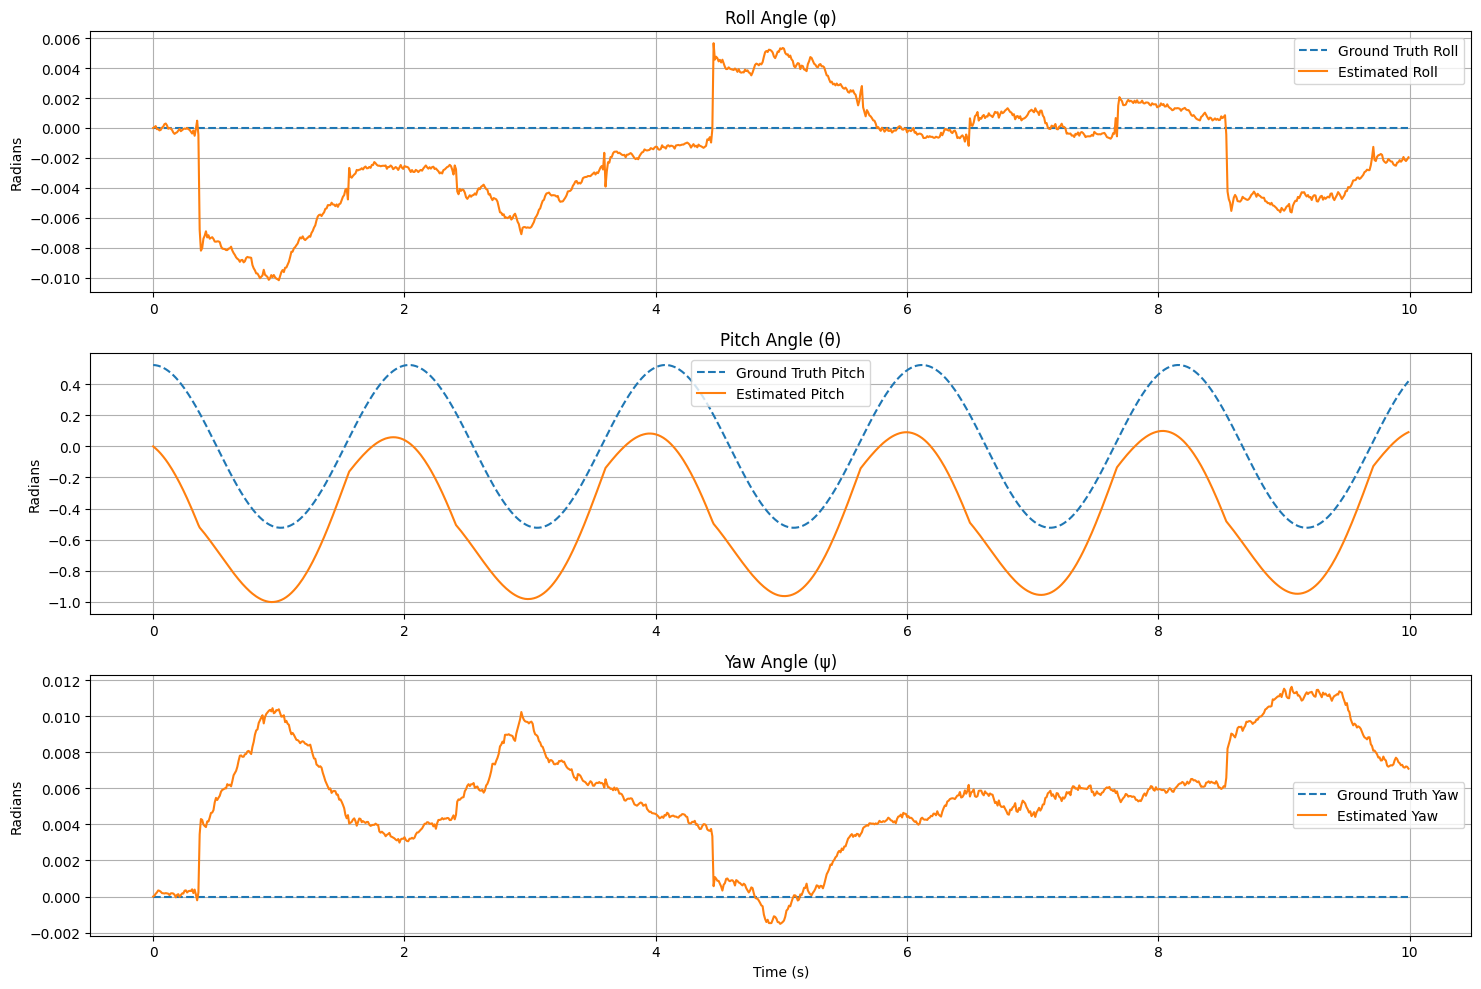

In [10]:

gt_data = synthetic_data['gt'].item()

t        = gt_data['t']
gt_roll  = gt_data['roll']
gt_pitch = gt_data['pitch']
gt_yaw   = gt_data['yaw']
gt_vx    = gt_data['vx']
gt_vy    = gt_data['vy']
gt_vz    = gt_data['vz']

est_roll  = euler_angles[:, 0]
est_pitch = euler_angles[:, 1]
est_yaw   = euler_angles[:, 2]

plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(t, gt_roll, label='Ground Truth Roll', linestyle='--')
plt.plot(t, est_roll, label='Estimated Roll')
plt.title('Roll Angle (φ)')
plt.ylabel('Radians')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, gt_pitch, label='Ground Truth Pitch', linestyle='--')
plt.plot(t, est_pitch, label='Estimated Pitch')
plt.title('Pitch Angle (θ)')
plt.ylabel('Radians')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, gt_yaw, label='Ground Truth Yaw', linestyle='--')
plt.plot(t, est_yaw, label='Estimated Yaw')
plt.title('Yaw Angle (ψ)')
plt.xlabel('Time (s)')
plt.ylabel('Radians')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()